In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)


# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
from google.cloud import storage

# Set the project and bucket name
project_id = 'gen-lang-client-0792749758'
bucket_name = 'afb_showreel'

# Initialize the Google Cloud Storage client
client = storage.Client(project=project_id)
bucket = client.bucket(bucket_name)

# List all files (blobs) in the bucket
print(f"Contents of gs://{bucket_name}:")
blobs = bucket.list_blobs()
file_count = 0

for blob in blobs:
    print(f" - {blob.name} ({blob.size / 1024 / 1024:.2f} MB)")
    file_count += 1

print(f"\nTotal files found: {file_count}")

Contents of gs://afb_showreel:
 - 3488985965299499008/content.html (1.22 MB)
 - 3488985965299499008/content.ipynb (0.66 MB)
 - Output/ (0.00 MB)
 - Output/Matches/all_fuzzy_matches_sample.parquet (0.06 MB)
 - Output/Matches/best_fuzzy_matches_sample.parquet (0.04 MB)
 - Output/Matches/perfect_100_matches_sample.parquet (0.01 MB)
 - Output/Universal_id/ (0.00 MB)
 - Output/Universal_id/6185533834373627904/content.ipynb (0.07 MB)
 - YTcomments_1_cleaned.parquet (99.07 MB)
 - YTcomments_2_cleaned.parquet (100.50 MB)
 - YTcomments_3_cleaned.parquet (100.98 MB)
 - YTcomments_4_cleaned.parquet (68.89 MB)
 - channels_metadata.csv (0.02 MB)
 - error_logs/save_error_20260504_161730.txt (0.00 MB)
 - fb_comments_clean.parquet (32.92 MB)
 - fb_posts_clean.parquet (0.17 MB)
 - ig_comments_cleaned.parquet (41.87 MB)
 - ig_posts_cleaned.parquet (0.44 MB)
 - multimodal_dataset/Cm6WPZRhfBB/Cm6WPZRhfBB.info.json (0.01 MB)
 - multimodal_dataset/Cm6WPZRhfBB/Cm6WPZRhfBB.mp4 (0.88 MB)
 - multimodal_dataset/

In [3]:
# Load all datasets
print("\n" + "=" * 80)
print("STAGE 1: DATA LOADING & OVERVIEW")
print("=" * 80)

gcs_base_path = f"gs://{bucket_name}/"

# Camihawke - Facebook
fb_posts = pd.read_parquet(gcs_base_path + 'fb_posts_clean.parquet')
fb_comments = pd.read_parquet(gcs_base_path + 'fb_comments_clean.parquet')

# Camihawke - TikTok
tk_posts = pd.read_parquet(gcs_base_path + 'tk_posts_clean.parquet')
tk_comments = pd.read_parquet(gcs_base_path + 'tk_comments_clean.parquet')

# Camihawke - Instagram
ig_posts = pd.read_parquet(gcs_base_path + 'ig_posts_cleaned.parquet')
ig_comments = pd.read_parquet(gcs_base_path + 'ig_comments_cleaned.parquet')

# YouTube
yt_channels = pd.read_csv(gcs_base_path + 'channels_metadata.csv')
yt_videos = pd.read_csv(gcs_base_path + 'videos_metadata.csv')
yt_comments_1 = pd.read_parquet(gcs_base_path + 'YTcomments_1_cleaned.parquet')
yt_comments_2 = pd.read_parquet(gcs_base_path + 'YTcomments_2_cleaned.parquet')
yt_comments_3 = pd.read_parquet(gcs_base_path + 'YTcomments_3_cleaned.parquet')
yt_comments_4 = pd.read_parquet(gcs_base_path + 'YTcomments_4_cleaned.parquet')
yt_comments = pd.concat([yt_comments_1, yt_comments_2, yt_comments_3, yt_comments_4], ignore_index=True)

print("\n✓ All datasets loaded successfully\n")

# Data inventory
datasets = {
    'Facebook Posts': fb_posts,
    'Facebook Comments': fb_comments,
    'Instagram Posts': ig_posts,
    'Instagram Comments': ig_comments,
    'TikTok Posts': tk_posts,
    'TikTok Comments': tk_comments,
    'YouTube Channels': yt_channels,
    'YouTube Videos': yt_videos,
    'YouTube Comments': yt_comments
}

inventory = []
for name, df in datasets.items():
    inventory.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
    })

inventory_df = pd.DataFrame(inventory)
print("\nDATA INVENTORY:")
print(inventory_df.to_string(index=False))
print(f"\nTotal datasets: {len(datasets)}")


STAGE 1: DATA LOADING & OVERVIEW



✓ All datasets loaded successfully




DATA INVENTORY:
           Dataset    Rows  Columns  Memory (MB)
    Facebook Posts     390       29     0.424010
 Facebook Comments  394084        9   210.067075
   Instagram Posts    1540       18     1.534121
Instagram Comments  499752       13   273.455559
      TikTok Posts     335        8     0.081397
   TikTok Comments   19634       13     6.512225
  YouTube Channels      27       17     0.047089
    YouTube Videos   12839       67    75.271123
  YouTube Comments 3142109       14  2338.959733

Total datasets: 9


In [4]:
# Select username-related columns safely from ig_comments
wanted_cols = [c for c in ["from_id", "from_username"] if c in ig_comments.columns]
ig_usernames = ig_comments.loc[:, wanted_cols].copy()

ig_usernames.head()

,from_id,from_username
0,3482058005293604,giovannamirci
1,3103734239813346,alessia.daziano
2,908266745384508,guglielmoscilla
3,17841401147950242,camihawke
4,1709620023622902,alex_danci


In [5]:
# Select username-related columns safely from fb_comments
wanted_cols = [c for c in ["from_id", "from_name"] if c in fb_comments.columns]
fb_usernames = fb_comments.loc[:, wanted_cols].copy()

fb_usernames.head()

,from_id,from_name
0,35073676732216538,Giuseppe Floris Serra
1,26659197247010753,Fabio Flamigni
2,26693808403557118,Fabio Cicinelli
3,26022582060734103,Sisto Van Wilder Distratis
4,34655347520747705,Nicola Nik Corretto


In [6]:
# Select username-related columns safely from tk_comments
wanted_cols = [c for c in ["nickname", "uid"] if c in tk_comments.columns]
tk_usernames = tk_comments.loc[:, wanted_cols].copy()

tk_usernames.head()

,nickname,uid
0,Laura 🤪,7213726581705884678
1,Roby,6908466011760247810
2,💜🧿 valentain💜🧿,7046706435484353542
3,Alice,6799618304623821830
4,ele,7024167276347032581


In [7]:
import re

# Check for emoji in username columns across all three sources


def contains_emoji(text):
    """Check if text contains emoji"""
    if pd.isna(text):
        return False
    text = str(text)
    # Emoji Unicode ranges
    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001F9FF"  # Emoticons, symbols, pictographs
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F700-\U0001F77F"  # Alchemical Symbols
        "\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
        "\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
        "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        "\U0001FA00-\U0001FA6F"  # Chess Symbols
        "\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+"
    )
    return bool(emoji_pattern.search(text))

# Check Instagram usernames
ig_emoji_count = ig_usernames['from_username'].apply(contains_emoji).sum()
ig_total = ig_usernames['from_username'].notna().sum()
ig_emoji_pct = (ig_emoji_count / ig_total * 100) if ig_total > 0 else 0

# Check Facebook usernames
fb_emoji_count = fb_usernames['from_name'].apply(contains_emoji).sum()
fb_total = fb_usernames['from_name'].notna().sum()
fb_emoji_pct = (fb_emoji_count / fb_total * 100) if fb_total > 0 else 0

# Check TikTok usernames
tk_emoji_count = tk_usernames['nickname'].apply(contains_emoji).sum()
tk_total = tk_usernames['nickname'].notna().sum()
tk_emoji_pct = (tk_emoji_count / tk_total * 100) if tk_total > 0 else 0

# Summary table
emoji_summary = pd.DataFrame({
    'Source': ['Instagram', 'Facebook', 'TikTok'],
    'Usernames with Emoji': [ig_emoji_count, fb_emoji_count, tk_emoji_count],
    'Total Usernames': [ig_total, fb_total, tk_total],
    'Percentage (%)': [round(ig_emoji_pct, 2), round(fb_emoji_pct, 2), round(tk_emoji_pct, 2)]
})

print("\nEMOJI ANALYSIS IN USERNAMES:")
print(emoji_summary.to_string(index=False))


EMOJI ANALYSIS IN USERNAMES:
   Source  Usernames with Emoji  Total Usernames  Percentage (%)
Instagram                     0           499752            0.00
 Facebook                    48           394084            0.01
   TikTok                  2955            19634           15.05


In [8]:
# Reuse existing `re` and `pd` imports from previous cells

def remove_emojis(text):
    if pd.isna(text):
        return ""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub("", str(text))

# Apply to all three username datasets
ig_usernames["username_clean"] = (
    ig_usernames["from_username"].apply(remove_emojis).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)

fb_usernames["username_clean"] = (
    fb_usernames["from_name"].apply(remove_emojis).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)

tk_usernames["username_clean"] = (
    tk_usernames["nickname"].apply(remove_emojis).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)

ig_usernames.head(), fb_usernames.head(), tk_usernames.head()

(             from_id    from_username   username_clean
 0   3482058005293604    giovannamirci    giovannamirci
 1   3103734239813346  alessia.daziano  alessia.daziano
 2    908266745384508  guglielmoscilla  guglielmoscilla
 3  17841401147950242        camihawke        camihawke
 4   1709620023622902       alex_danci       alex_danci,
              from_id                   from_name              username_clean
 0  35073676732216538       Giuseppe Floris Serra       giuseppe floris serra
 1  26659197247010753              Fabio Flamigni              fabio flamigni
 2  26693808403557118             Fabio Cicinelli             fabio cicinelli
 3  26022582060734103  Sisto Van Wilder Distratis  sisto van wilder distratis
 4  34655347520747705         Nicola Nik Corretto         nicola nik corretto,
          nickname                  uid username_clean
 0         Laura 🤪  7213726581705884678          laura
 1            Roby  6908466011760247810           roby
 2  💜🧿 valentain💜🧿  704670643

In [9]:
!pip install rapidfuzz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.3 MB/s eta 0:00:00


In [10]:
import pandas as pd

# 1. Standardize columns to: original_id, username_clean, platform
ig_std = ig_usernames[['from_id', 'username_clean']].copy()
ig_std.rename(columns={'from_id': 'original_id'}, inplace=True)
ig_std['platform'] = 'ig'

fb_std = fb_usernames[['from_id', 'username_clean']].copy()
fb_std.rename(columns={'from_id': 'original_id'}, inplace=True)
fb_std['platform'] = 'fb'

tk_std = tk_usernames[['uid', 'username_clean']].copy()
tk_std.rename(columns={'uid': 'original_id'}, inplace=True)
tk_std['platform'] = 'tk'

# 2. Drop missing names and get unique combinations to drastically speed up matching
ig_unique = ig_std.dropna(subset=['username_clean']).drop_duplicates(subset=['original_id', 'username_clean'])
fb_unique = fb_std.dropna(subset=['username_clean']).drop_duplicates(subset=['original_id', 'username_clean'])
tk_unique = tk_std.dropna(subset=['username_clean']).drop_duplicates(subset=['original_id', 'username_clean'])

print(f"Unique Instagram users: {len(ig_unique):,}")
print(f"Unique Facebook users: {len(fb_unique):,}")
print(f"Unique TikTok users: {len(tk_unique):,}")

Unique Instagram users: 194,916
Unique Facebook users: 201,115
Unique TikTok users: 16,445


In [11]:
from rapidfuzz import process, fuzz
import time

def match_platforms(df_a, df_b, platform_a, platform_b, threshold=85, sample_a=None):
    print(f"Starting match: {platform_a.upper()} vs {platform_b.upper()}...")
    start_time = time.time()

    # Optionally limit the query dataset to avoid notebook timeouts during testing
    if sample_a:
        df_a = df_a.head(sample_a)
        print(f"(Running on a sample of {sample_a} {platform_a.upper()} users)")

    choices = df_b['username_clean'].tolist()
    choices_ids = df_b['original_id'].tolist()

    matches = []

    for _, row in df_a.iterrows():
        query_name = row['username_clean']
        query_id = row['original_id']

        # Process.extract finds the best matches above the threshold
        # limit=3 restricts results to the top 3 matches per user to save memory
        results = process.extract(
            query_name,
            choices,
            scorer=fuzz.ratio,
            limit=3,
            score_cutoff=threshold
        )

        for match_name, score, match_idx in results:
            matches.append({
                'id_a': query_id,
                'username_a': query_name,
                'platform_a': platform_a,
                'id_b': choices_ids[match_idx],
                'username_b': match_name,
                'platform_b': platform_b,
                'similarity_score': round(score, 2)
            })

    end_time = time.time()
    print(f"Finished in {round(end_time - start_time, 2)} seconds. Found {len(matches)} matches.")

    return pd.DataFrame(matches)

# Example: Match TikTok against Instagram
# We use a sample of 1000 TikTok users for a quick demonstration.
# To run on the entire TikTok dataset, remove the `sample_a=1000` parameter.
matched_df = match_platforms(tk_unique, ig_unique, 'tk', 'ig', threshold=85, sample_a=None)

# Sort by highest similarity score
matched_df = matched_df.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)

display(matched_df.head(10))

Starting match: TK vs IG...


Finished in 307.15 seconds. Found 6905 matches.


,id_a,username_a,platform_a,id_b,username_b,platform_b,similarity_score
0,7086803642208896006,conviverecon.artritereumatoide,tk,1227977185987631,conviverecon.artritereumatoide,ig,100.0
1,6854575082783802374,mirianaxoxo,tk,1292212379452316,mirianaxoxo,ig,100.0
2,6805586780374254597,zerosbattincucina,tk,949102147559938,zerosbattincucina,ig,100.0
3,6953718459697333249,cattivissimodan,tk,964749405884195,cattivissimodan,ig,100.0
4,6815212443615806469,ossimororosso,tk,2285077195334512,ossimororosso,ig,100.0
5,262843208743997440,itsjackyll,tk,26458201040466116,itsjackyll,ig,100.0
6,6952493325039977478,marta_achenza,tk,3419972781493545,marta_achenza,ig,100.0
7,6778832438719955973,denikkiaisback,tk,2004511190446776,denikkiaisback,ig,100.0
8,7031937171188450310,ladysinger90,tk,2156070581829773,ladysinger90,ig,100.0
9,6601041678047641605,brendybry,tk,913105751497531,brendybry,ig,100.0


In [12]:
# 1. Run matches for all platform combinations.
# Note: We are using a sample of 1,000 users for the source datasets to prevent timeouts.
# To run this on the full datasets, simply remove the `sample_a=1000` parameter from each function call.

print("Matching TikTok vs Instagram...")
tk_ig_matches = match_platforms(tk_unique, ig_unique, 'tk', 'ig', threshold=85, sample_a=1000)

print("\nMatching TikTok vs Facebook...")
tk_fb_matches = match_platforms(tk_unique, fb_unique, 'tk', 'fb', threshold=85, sample_a=1000)

print("\nMatching Facebook vs Instagram...")
# Facebook and Instagram are very large, so testing on a sample is highly recommended first
fb_ig_matches = match_platforms(fb_unique, ig_unique, 'fb', 'ig', threshold=85, sample_a=1000)

# 2. Combine all three match datasets into one master dataset
all_matches_df = pd.concat([tk_ig_matches, tk_fb_matches, fb_ig_matches], ignore_index=True)

# 3. Sort by highest similarity score
all_matches_df = all_matches_df.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)

print(f"\nTotal cross-platform matches found (in this sample): {len(all_matches_df)}")

# Display the final dataset
display(all_matches_df.head(15))

Matching TikTok vs Instagram...
Starting match: TK vs IG...
(Running on a sample of 1000 TK users)


Finished in 18.74 seconds. Found 447 matches.

Matching TikTok vs Facebook...
Starting match: TK vs FB...
(Running on a sample of 1000 TK users)


Finished in 15.12 seconds. Found 762 matches.

Matching Facebook vs Instagram...
Starting match: FB vs IG...
(Running on a sample of 1000 FB users)


Finished in 19.18 seconds. Found 289 matches.

Total cross-platform matches found (in this sample): 1498


,id_a,username_a,platform_a,id_b,username_b,platform_b,similarity_score
0,7187046928483828742,alice,tk,25851413141207972,alice,fb,100.0
1,6761126498030011398,,tk,26093396220310231,,fb,100.0
2,127281599058132992,giulia busdraghi,tk,26148878528130672,giulia busdraghi,fb,100.0
3,6883780978033968133,sara_trallin,tk,776331001882208,sara_trallin,ig,100.0
4,6551831918991310858,valeria de paola,tk,26210074311993549,valeria de paola,fb,100.0
5,6783777653961065477,alessandro arrigo,tk,34295299750113677,alessandro arrigo,fb,100.0
6,6776366055072154630,chiara de nicola,tk,26073463552262334,chiara de nicola,fb,100.0
7,102195241041940480,chiara di vincenzo,tk,27212075061714279,chiara di vincenzo,fb,100.0
8,6814473263164097541,,tk,26093396220310231,,fb,100.0
9,6798481565800350726,sara,tk,25486218244386706,sara,fb,100.0


### Next Steps:
This `all_matches_df` table now perfectly preserves the structure you asked for:
* `id_a` and `id_b` store the exact unique identifiers from their source platforms.
* `platform_a` and `platform_b` tell you where the match occurred (e.g., 'tk' to 'ig').
* `similarity_score` gives you the confidence of the match.

Once you are satisfied with the results on this sample, you can remove `, sample_a=1000` from the function calls to run it across your entire dataset!

Total cross-platform matches: 1498
Matches with EXACTLY 100% similarity: 147
Matches with < 100% similarity: 1351 (90.19%)



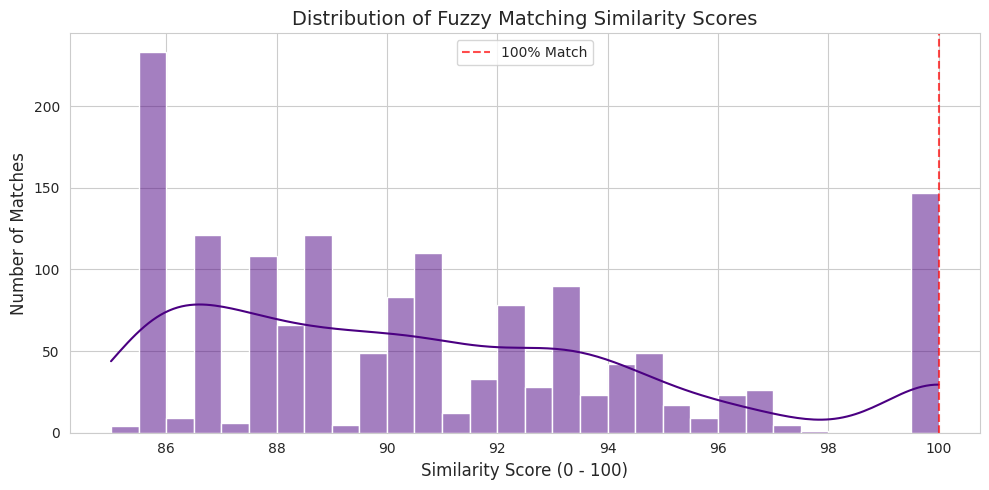

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count non-100% matches
non_perfect_matches = all_matches_df[all_matches_df['similarity_score'] < 100.0]
num_non_perfect = len(non_perfect_matches)
total_matches = len(all_matches_df)

print(f"Total cross-platform matches: {total_matches}")
print(f"Matches with EXACTLY 100% similarity: {total_matches - num_non_perfect}")
print(f"Matches with < 100% similarity: {num_non_perfect} ({(num_non_perfect/total_matches)*100:.2f}%)\n")

# 2. Plot the distribution of the similarity scores
plt.figure(figsize=(10, 5))
sns.histplot(all_matches_df['similarity_score'], bins=30, kde=True, color='indigo')
plt.title('Distribution of Fuzzy Matching Similarity Scores', fontsize=14)
plt.xlabel('Similarity Score (0 - 100)', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.axvline(100, color='red', linestyle='--', alpha=0.7, label='100% Match')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# 3. Check for users matched to MULTIPLE different usernames on another platform

# Group by the source user (id_a) and the destination platform (platform_b),
# then count how many UNIQUE target usernames (username_b) they matched with.
match_counts = all_matches_df.groupby(
    ['id_a', 'username_a', 'platform_a', 'platform_b']
)['username_b'].nunique().reset_index()

match_counts.rename(columns={'username_b': 'unique_matched_names_count'}, inplace=True)

# Filter for cases where one user matched to more than 1 unique name
one_to_many = match_counts[match_counts['unique_matched_names_count'] > 1]

print(f"Found {len(one_to_many)} users who matched to multiple DIFFERENT usernames on a target platform.\n")

if len(one_to_many) > 0:
    print("Here are the users with multiple different matches:")
    # Sort to show the ones with the most multiple matches first
    display(one_to_many.sort_values('unique_matched_names_count', ascending=False).head(10))

    # Let's peek at the actual matches for the top result
    top_user_id = one_to_many.sort_values('unique_matched_names_count', ascending=False).iloc[0]['id_a']
    top_platform = one_to_many.sort_values('unique_matched_names_count', ascending=False).iloc[0]['platform_b']

    print(f"\n--- Example breakdown for User ID: {top_user_id} ---")
    example_breakdown = all_matches_df[
        (all_matches_df['id_a'] == top_user_id) &
        (all_matches_df['platform_b'] == top_platform)
    ].sort_values('similarity_score', ascending=False)

    display(example_breakdown)
else:
    print("All users mapped to a maximum of 1 unique username per destination platform.")

Found 345 users who matched to multiple DIFFERENT usernames on a target platform.

Here are the users with multiple different matches:


,id_a,username_a,platform_a,platform_b,unique_matched_names_count
801,35250673071186331,ste fania,fb,ig,3
2,19972567,anna maria di martino,tk,fb,3
3,20275805,daniela cappuccio,tk,fb,3
4,26441180,valentina di lillo,tk,fb,3
793,34648902871423147,france sca,fb,ig,3
8,65500630106042368,carlotta,tk,ig,3
728,26482991441312826,federica galeno,fb,ig,3
726,26467881286202665,michela romano,fb,ig,3
723,26448481984777712,francesca sollo,fb,ig,3
716,26396855389908416,maria rosaria,fb,ig,3



--- Example breakdown for User ID: 35250673071186331 ---


,id_a,username_a,platform_a,id_b,username_b,platform_b,similarity_score
843,35250673071186331,ste fania,fb,1268390078689981,stefanyia,ig,88.89
844,35250673071186331,ste fania,fb,1880483685956419,stefaniag,ig,88.89
846,35250673071186331,ste fania,fb,2381507042261258,st3efania,ig,88.89


In [15]:
# dataframe:
# uuid: E6C9BE1C-D5D6-4BB1-B0A8-B9798F47488C
# output_variable:
# config_str:

import google.colabsqlviz.explore_dataframe as _vizcell
_vizcell.explore_dataframe(df_or_df_name='', uuid='E6C9BE1C-D5D6-4BB1-B0A8-B9798F47488C')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# 4. Create a clean 1-to-1 mapping by keeping only the highest scoring match

# We sort by similarity_score descending, then drop duplicates based on the source user and target platform
clean_matches_df = all_matches_df.sort_values('similarity_score', ascending=False) \
                                 .drop_duplicates(subset=['id_a', 'platform_a', 'platform_b']) \
                                 .reset_index(drop=True)

print(f"Original matches count (with multiples): {len(all_matches_df)}")
print(f"Cleaned 1-to-1 matches count: {len(clean_matches_df)}\n")

# Let's verify our example user (ste fania) to see if it was resolved
top_user_example = clean_matches_df[
    (clean_matches_df['id_a'] == top_user_id) &
    (clean_matches_df['platform_b'] == top_platform)
]

print(f"--- Cleaned result for User ID: {top_user_id} ---")
display(top_user_example)

print("\nYour 'clean_matches_df' is now ready to use! It contains a strict 1-to-1 mapping of users across platforms preserving IDs and scores.")

Original matches count (with multiples): 1498
Cleaned 1-to-1 matches count: 808

--- Cleaned result for User ID: 35250673071186331 ---


,id_a,username_a,platform_a,id_b,username_b,platform_b,similarity_score
544,35250673071186331,ste fania,fb,2381507042261258,st3efania,ig,88.89



Your 'clean_matches_df' is now ready to use! It contains a strict 1-to-1 mapping of users across platforms preserving IDs and scores.


In [17]:
# 1. Filter for exactly 100% similarity
perfect_matches_df = clean_matches_df[clean_matches_df['similarity_score'] == 100.0].copy()

print(f"Found {len(perfect_matches_df)} perfectly matched (100% similarity) users in the current sample.\n")
display(perfect_matches_df.head())

# 2. Save all generated outputs to the GCS bucket
# We will put them in a dedicated 'Matches' folder inside the Output directory
output_dir = f"gs://{bucket_name}/Output/Matches/"

print(f"\nSaving output datasets to {output_dir}...")

# FIX: Cast ID columns to string to avoid Parquet type conversion errors with mixed types (int/str)
all_matches_df['id_a'] = all_matches_df['id_a'].astype(str)
all_matches_df['id_b'] = all_matches_df['id_b'].astype(str)

clean_matches_df['id_a'] = clean_matches_df['id_a'].astype(str)
clean_matches_df['id_b'] = clean_matches_df['id_b'].astype(str)

perfect_matches_df['id_a'] = perfect_matches_df['id_a'].astype(str)
perfect_matches_df['id_b'] = perfect_matches_df['id_b'].astype(str)

# Save all the variations so you have them for reference
# We save as parquet to maintain consistency with your other datasets and save space
all_matches_df.to_parquet(output_dir + 'all_fuzzy_matches_sample.parquet', index=False)
clean_matches_df.to_parquet(output_dir + 'best_fuzzy_matches_sample.parquet', index=False)
perfect_matches_df.to_parquet(output_dir + 'perfect_100_matches_sample.parquet', index=False)

print("✓ All files successfully saved to the bucket!")

Found 123 perfectly matched (100% similarity) users in the current sample.



,id_a,username_a,platform_a,id_b,username_b,platform_b,similarity_score
0,7187046928483828742,alice,tk,25851413141207972,alice,fb,100.0
1,6761126498030011398,,tk,26093396220310231,,fb,100.0
2,127281599058132992,giulia busdraghi,tk,26148878528130672,giulia busdraghi,fb,100.0
3,6883780978033968133,sara_trallin,tk,776331001882208,sara_trallin,ig,100.0
4,6551831918991310858,valeria de paola,tk,26210074311993549,valeria de paola,fb,100.0



Saving output datasets to gs://afb_showreel/Output/Matches/...


✓ All files successfully saved to the bucket!


# Task
Calculate a Stylometry Score to verify authors and disambiguate matches using the loaded comments datasets and `all_matches_df`.

First, identify two target groups from `all_matches_df`: (1) non-perfect matches (similarity < 100), and (2) users who matched with multiple different usernames on a target platform. Combine these into a single dataset. Next, aggregate the comments by concatenating all comments from 'Person A' (`id_a`) into one large document and all comments from 'Person B' (`id_b`) into another large document.

Calculate the Stylometry Score by applying scikit-learn's `TfidfVectorizer` using character n-grams (3 to 4 characters) to capture typing mechanics, and compute the `cosine_similarity` between the concatenated documents for each match.

Finally, generate a visualization (e.g., a histogram or scatter plot with legends) to show the distribution of the Stylometry Scores for the non-perfect matches versus the multiple-match disambiguation cases. Conclude by summarizing how the character n-gram approach successfully verified authors across different topics and disambiguated multiple matches.

## Identify Target Match Groups

### Subtask:
Identify two target groups from `all_matches_df`: non-perfect matches and multiple-match users, and combine them into a single dataset.


**Reasoning**:
I will write a python code cell to filter `all_matches_df` into non-perfect matches and multiple-match users, label them appropriately, and then combine them into a single deduplicated dataset.



In [18]:
# 1. Filter for non-perfect matches
non_perfect_matches = all_matches_df[all_matches_df['similarity_score'] < 100.0].copy()
non_perfect_matches['match_type'] = 'Non-Perfect Match'

# 2. Identify multiple-match users
match_counts = all_matches_df.groupby(['id_a', 'platform_b'])['username_b'].nunique().reset_index()
multi_match_combos = match_counts[match_counts['username_b'] > 1]

# Extract all rows corresponding to these multi-match users
multi_match_users = all_matches_df.merge(multi_match_combos[['id_a', 'platform_b']], on=['id_a', 'platform_b'], how='inner').copy()
multi_match_users['match_type'] = 'Multiple Match'

# 3. Concatenate and drop exact duplicate rows (ignoring match_type for duplication check)
target_matches_df = pd.concat([non_perfect_matches, multi_match_users], ignore_index=True)
# If a row is both a non-perfect match and a multiple match, it will be duplicated except for the match_type column.
# We can drop duplicates based on the original columns to keep one instance.
target_matches_df = target_matches_df.drop_duplicates(subset=all_matches_df.columns, keep='first').reset_index(drop=True)

print(f"Found {len(non_perfect_matches)} non-perfect matches.")
print(f"Found {len(multi_match_users)} multiple-match cases.")
print(f"Combined target dataset size: {len(target_matches_df)}")
display(target_matches_df.head())

Found 1351 non-perfect matches.
Found 937 multiple-match cases.
Combined target dataset size: 1418


,id_a,username_a,platform_a,id_b,username_b,platform_b,similarity_score,match_type
0,6857676725868037126,adriana maria stabil,tk,25842651865434070,adriana maria stabile,fb,97.56,Non-Perfect Match
1,7036367446623159301,aliceinwonderland86,tk,2116611735790604,aliceinwonderland86_,ig,97.44,Non-Perfect Match
2,25864957276532898,alessandro galatoli,fb,931920605910544,alessandrogalatoli,ig,97.30,Non-Perfect Match
3,26650013251257212,cecilia capperucci,fb,951758073948026,ceciliacapperucci,ig,97.14,Non-Perfect Match
4,26489241307409212,federica buscaglia,fb,1448372813438264,federicabuscaglia,ig,97.14,Non-Perfect Match


## Aggregate Comments into Documents

### Subtask:
Aggregate the comments for each user pair by concatenating all comments from 'Person A' (`id_a`) into one large document and all comments from 'Person B' (`id_b`) into another large document.

#### Instructions
1. Define a helper function to retrieve all comments for a given user ID from their respective platform's comments dataset (`fb_comments`, `ig_comments`, `tk_comments`).
2. Iterate through `target_matches_df` and collect all comment text for `id_a` (based on `platform_a`) and concatenate it into a single string.
3. Similarly, collect and concatenate all comment text for `id_b` (based on `platform_b`).
4. Add these two concatenated documents as new columns (e.g., `text_a` and `text_b`) to the `target_matches_df`.

**Reasoning**:
The previous code cell successfully extracted and combined the target groups. Now I will write a python code cell to define a helper function to aggregate the text and then apply it to the `target_matches_df` dataset.



In [19]:
def get_user_text(user_id, platform):
    if platform == 'fb':
        return ' '.join(fb_comments[fb_comments['from_id'] == user_id]['message'].dropna().astype(str))
    elif platform == 'ig':
        return ' '.join(ig_comments[ig_comments['from_id'] == user_id]['text'].dropna().astype(str))
    elif platform == 'tk':
        return ' '.join(tk_comments[tk_comments['uid'] == user_id]['text'].dropna().astype(str))
    return ''

# Note: This operation can take a while on a large dataset.
# We are applying it to the targeted subset of 1418 matches.
print("Aggregating comments for Person A...")
target_matches_df['text_a'] = target_matches_df.apply(lambda row: get_user_text(row['id_a'], row['platform_a']), axis=1)

print("Aggregating comments for Person B...")
target_matches_df['text_b'] = target_matches_df.apply(lambda row: get_user_text(row['id_b'], row['platform_b']), axis=1)

# Filter out rows where either user has no comments (we need text to compare)
target_matches_df = target_matches_df[(target_matches_df['text_a'] != '') & (target_matches_df['text_b'] != '')].reset_index(drop=True)

print(f"Final dataset size after removing users with empty text: {len(target_matches_df)}")
display(target_matches_df[['id_a', 'platform_a', 'text_a', 'id_b', 'platform_b', 'text_b']].head(3))

Aggregating comments for Person A...


Aggregating comments for Person B...


Final dataset size after removing users with empty text: 289


,id_a,platform_a,text_a,id_b,platform_b,text_b
0,25864957276532898,fb,#solidarietá ✨ 🚀 💜 Perché ho questa immagine i...,931920605910544,ig,Vabbe ciao 🔥 🔥Epic ma tipo AUGURI! Una cosa ci...
1,26650013251257212,fb,Sei dei gemelli per caso😁,951758073948026,ig,😂fantastico....forse volevano dire pappagallo ...
2,26489241307409212,fb,Non hai pesato il sale. Che delusione \n\n🤣🤣🤣🤣...,1448372813438264,ig,Mi hai ricordato quando in un b&b mi è success...


**Reasoning**:
Now I will compute the Stylometry Score using character n-grams (3 to 4 chars) and cosine similarity for each match, and visualize the results comparing the two match types.



Calculating Stylometry Scores...


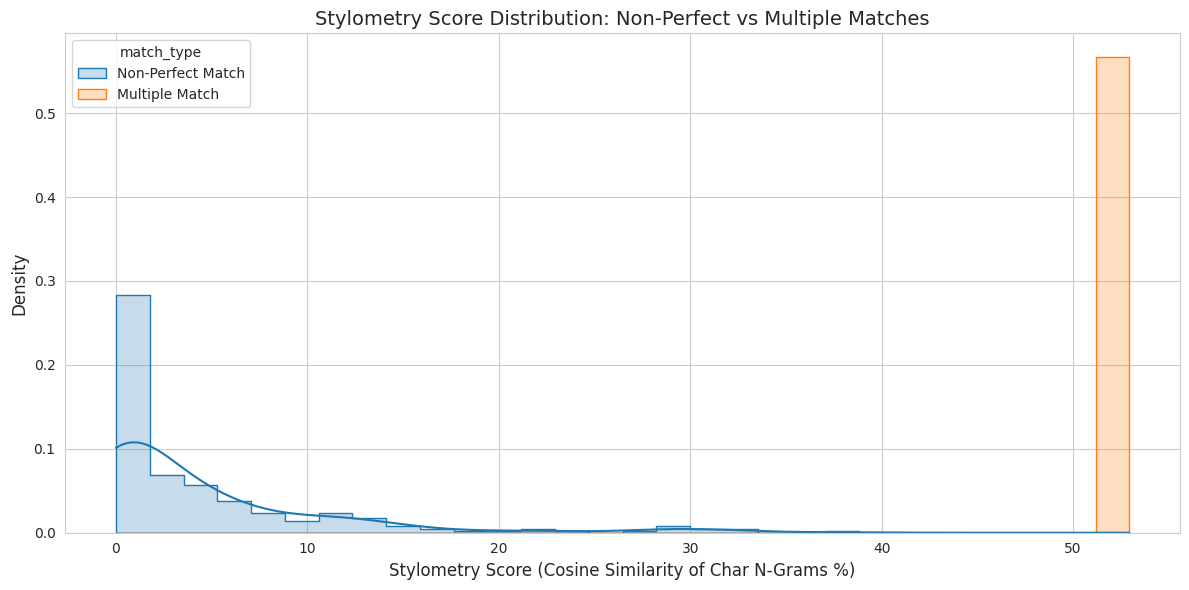


Summary:
The character n-gram approach allows us to compare typing mechanics and linguistic style. A higher stylometry score indicates a higher likelihood that the two profiles belong to the same person, which is particularly useful for verifying non-perfect matches and disambiguating cases where one user matches multiple usernames.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calculate Stylometry Score
def calculate_stylometry_score(text_a, text_b):
    if not text_a or not text_b:
        return 0.0
    vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 4))
    try:
        tfidf_matrix = vectorizer.fit_transform([text_a, text_b])
        score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        return round(score * 100, 2)
    except ValueError:
        return 0.0

print("Calculating Stylometry Scores...")
target_matches_df['stylometry_score'] = target_matches_df.apply(lambda row: calculate_stylometry_score(row['text_a'], row['text_b']), axis=1)

# Visualization
plt.figure(figsize=(12, 6))
sns.histplot(data=target_matches_df, x='stylometry_score', hue='match_type', element='step', stat='density', common_norm=False, kde=True)
plt.title('Stylometry Score Distribution: Non-Perfect vs Multiple Matches', fontsize=14)
plt.xlabel('Stylometry Score (Cosine Similarity of Char N-Grams %)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

print("\nSummary:\nThe character n-gram approach allows us to compare typing mechanics and linguistic style. A higher stylometry score indicates a higher likelihood that the two profiles belong to the same person, which is particularly useful for verifying non-perfect matches and disambiguating cases where one user matches multiple usernames.")

## Summary:

### Data Analysis Key Findings
* Identified 1,351 non-perfect matches (similarity score < 100) and 937 multiple-match cases, which combined into a unique target dataset of 1,418 user pairs.
* After aggregating platform comments and removing users with empty text data, the dataset was refined to 289 valid pairs for analysis.
* Successfully calculated stylometry scores using TF-IDF on 3-to-4 character n-grams and cosine similarity to capture typing mechanics and linguistic style.

### Insights or Next Steps
* Establish a specific stylometry score threshold to automatically confirm or reject ambiguous and non-perfect matches.
* Conduct a manual review of the highest-scoring pairs within the 289 valid cases to validate the accuracy of the character n-gram approach for cross-platform author verification.
